# Exploration approfondie de la base d'apprentissage

In [1]:
import pandas as pd
import sys
import os
import warnings
import pingouin as pg

warnings.filterwarnings("ignore")

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

from eda import *

In [2]:
# Configuration
FILE_PATH = "../data_finale/val.csv"
TARGET    = "market_value_in_eur"
dossier_sauvegarde = "../outputs/eda"

In [3]:
# Chargement de la base de données

df_base = pd.read_csv(FILE_PATH)

In [4]:
print("Types des variables")

analyser_types(df_base)

Types des variables
Analyse des types de variables
Variables numériques   : 150
Variables catégorielles: 4


Analyse des valeurs manquantes
                         nb_missing    pct
xg                              926  34.80
xg_buildup                      926  34.80
xa_nor                          926  34.80
xa                              926  34.80
xg_nor                          926  34.80
xg_buildup_nor                  926  34.80
contrat_jours_restants          339  12.74
Subs_Mn/Sub                     338  12.70
Subs_Mn/Sub_nor                 338  12.70
height_in_cm                    149   5.60
market_value_in_eur             146   5.49
market_value_in_eur_nor         146   5.49
Team Success_On-Off              19   0.71
Team Success_PPM_nor              3   0.11
Team Success_PPM                  3   0.11

Graphique sauvegardé sous : ..\outputs\eda\valeurs_manquantes.png


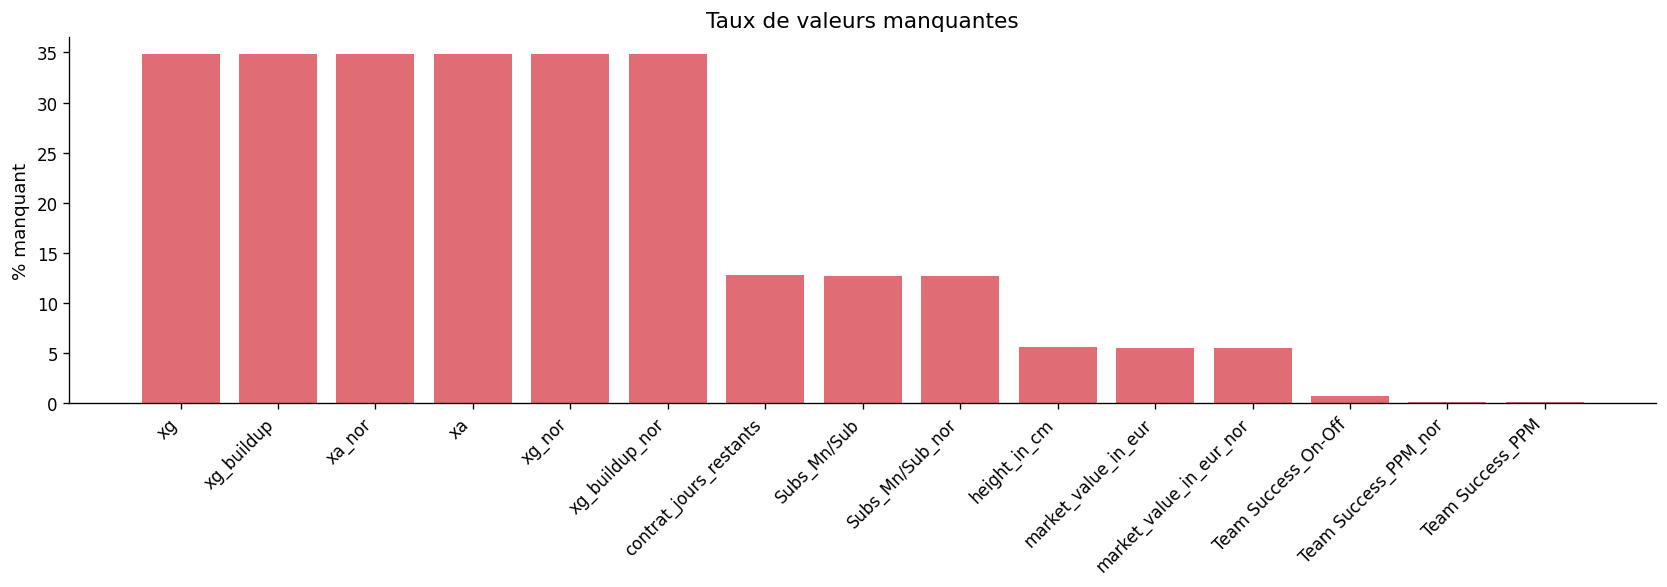

In [5]:
analyser_valeurs_manquantes(df_base, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la variable cible : market_value_in_eur
count          2,515
mean      10,965,209
std       15,049,325
min           50,000
25%        2,000,000
50%        5,400,000
75%       14,500,000
max      180,000,000
Name: market_value_in_eur, dtype: str

Skewness : 3.22
Kurtosis : 16.42

Graphique sauvegardé sous : ..\outputs\eda\distribution_market_value_in_eur.png


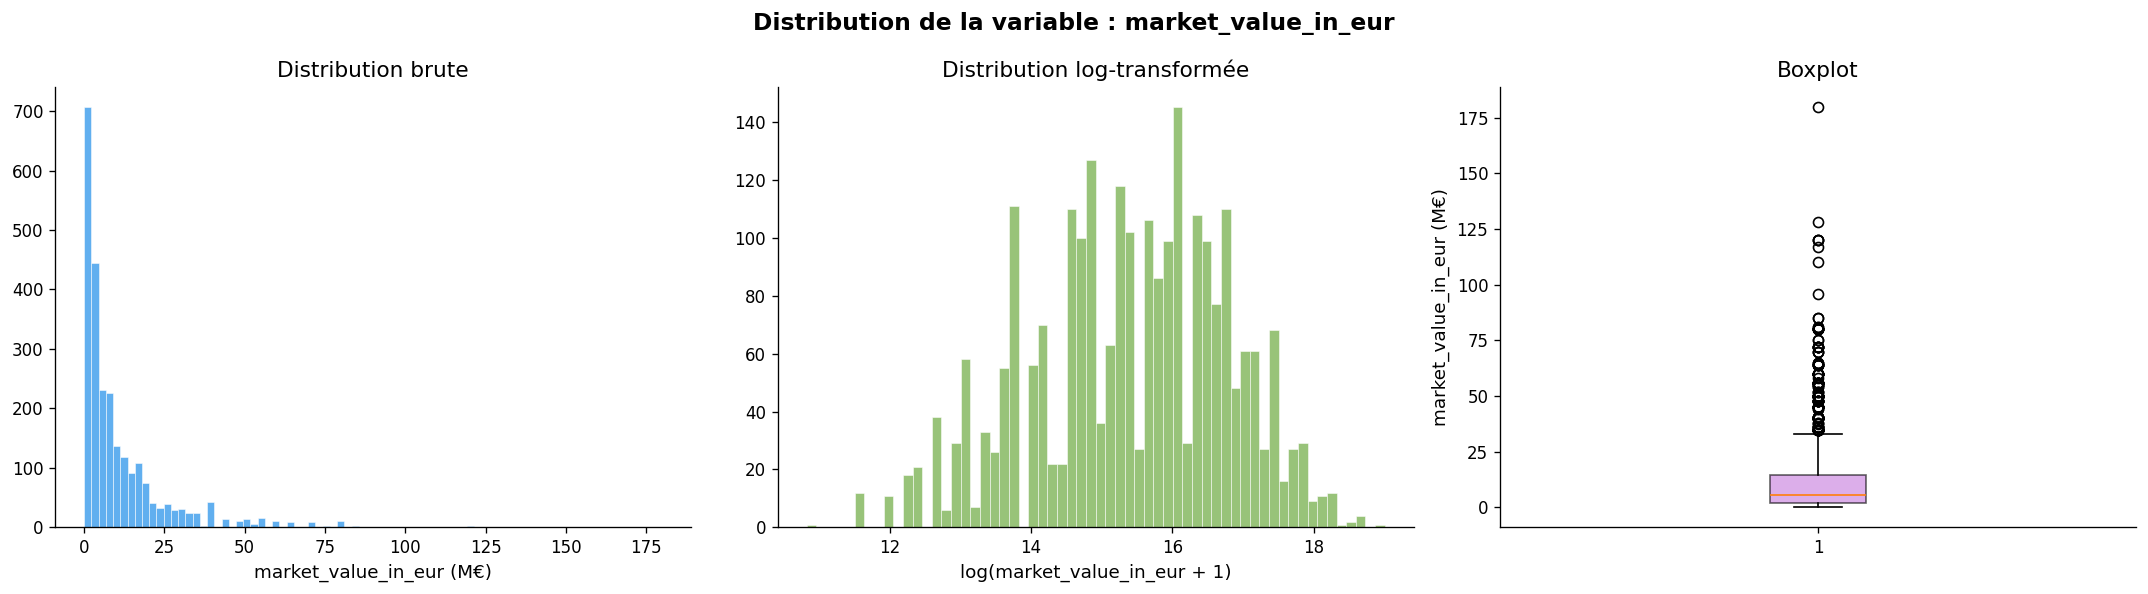

In [6]:
analyser_variable_cible(df_base, target_col=TARGET, dossier_sauvegarde=dossier_sauvegarde)

Distributions des variables numériques clés

Graphique sauvegardé sous : ..\outputs\eda\distributions_variables_numeriques_cles.png


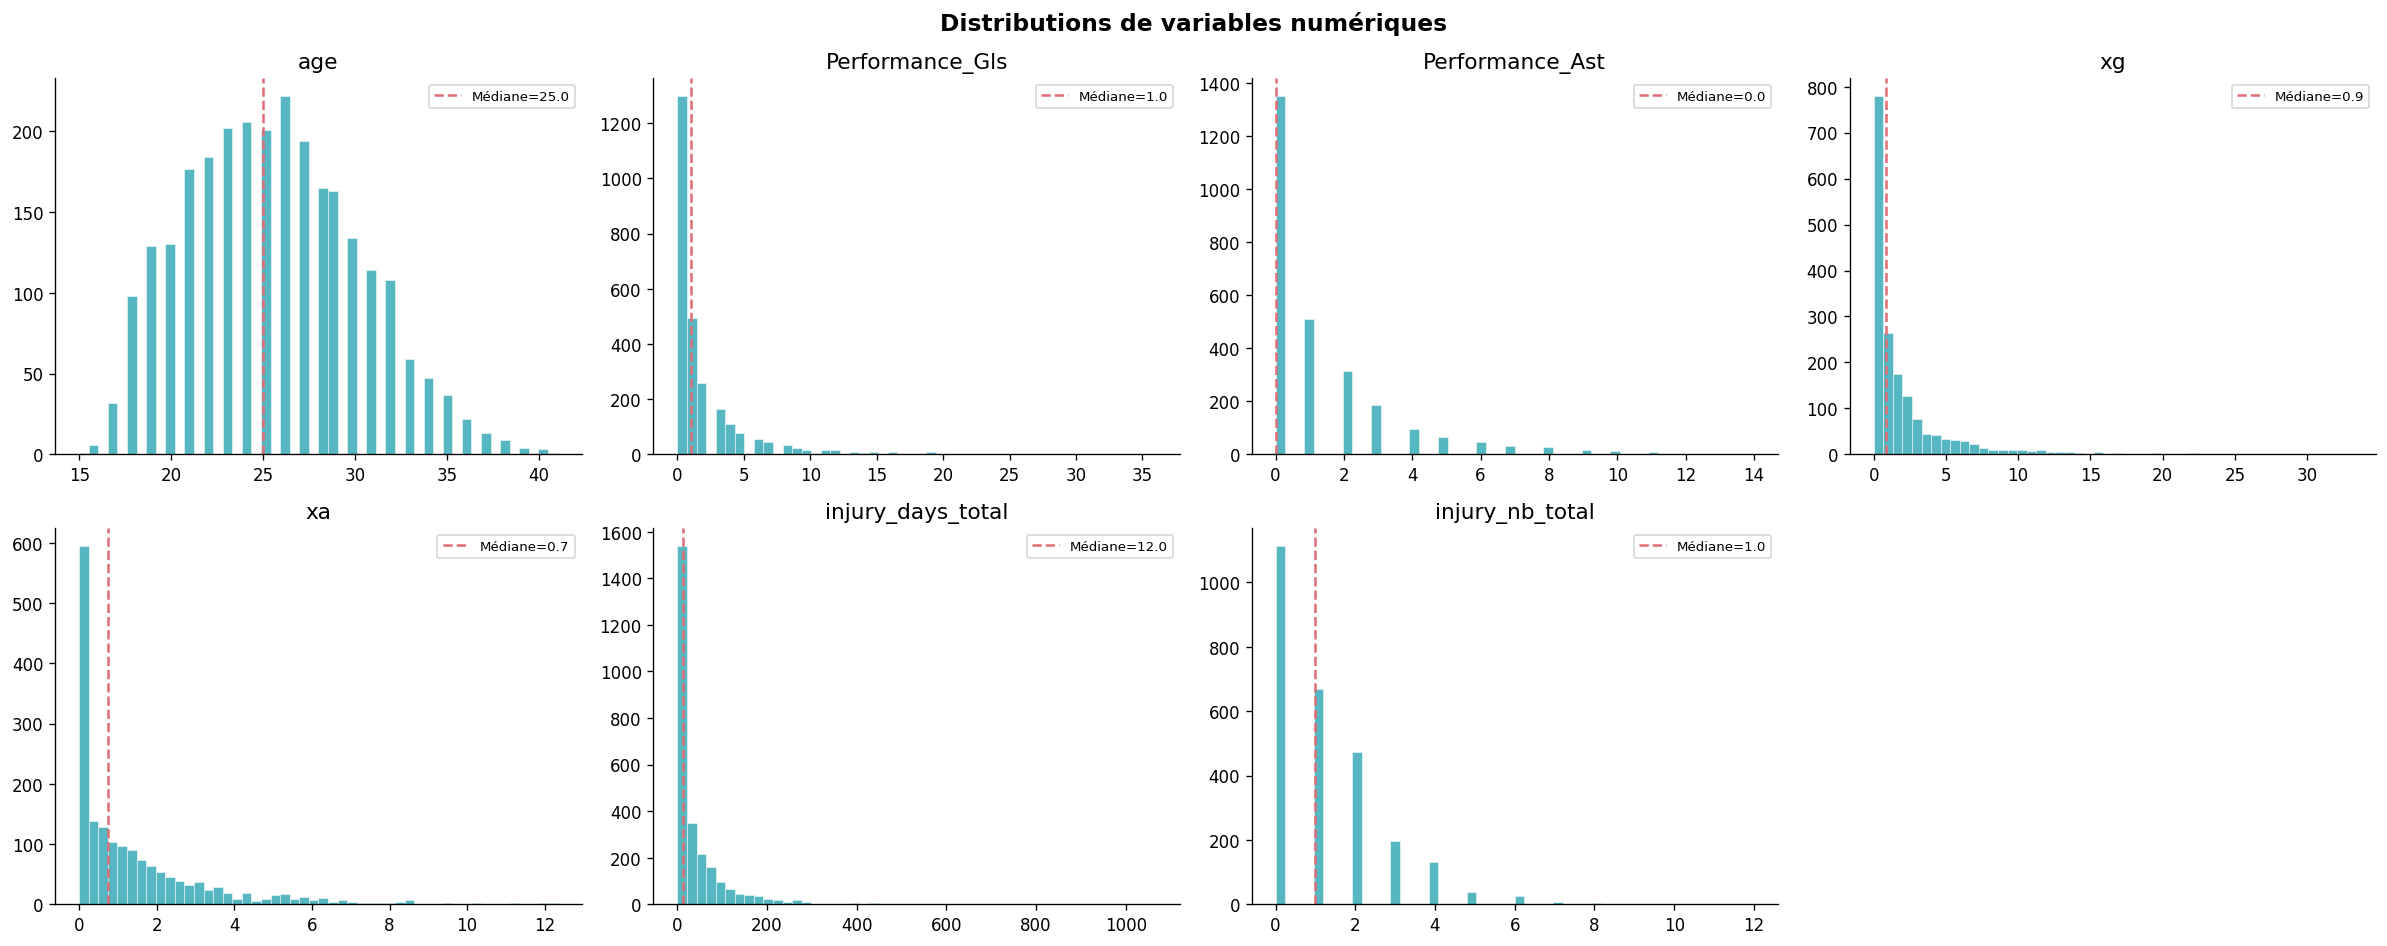

In [7]:
analyser_distributions_numeriques(df_base, cols_a_analyser=None, dossier_sauvegarde=dossier_sauvegarde)

Analyse des variables catégorielles

league (5 modalités encodées) :
ESP-La Liga           574
ITA-Serie A           569
ENG-Premier League    542
FRA-Ligue 1           505
GER-Bundesliga        471

players_top_nations.png sauvegardé


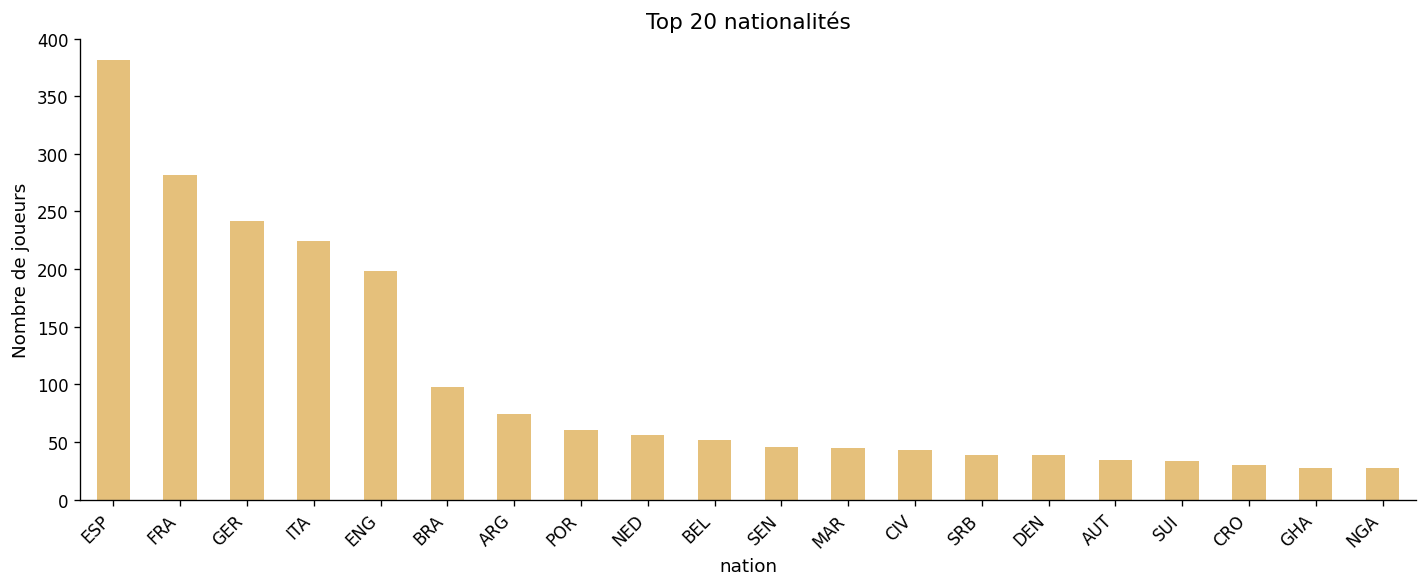

league.png sauvegardé


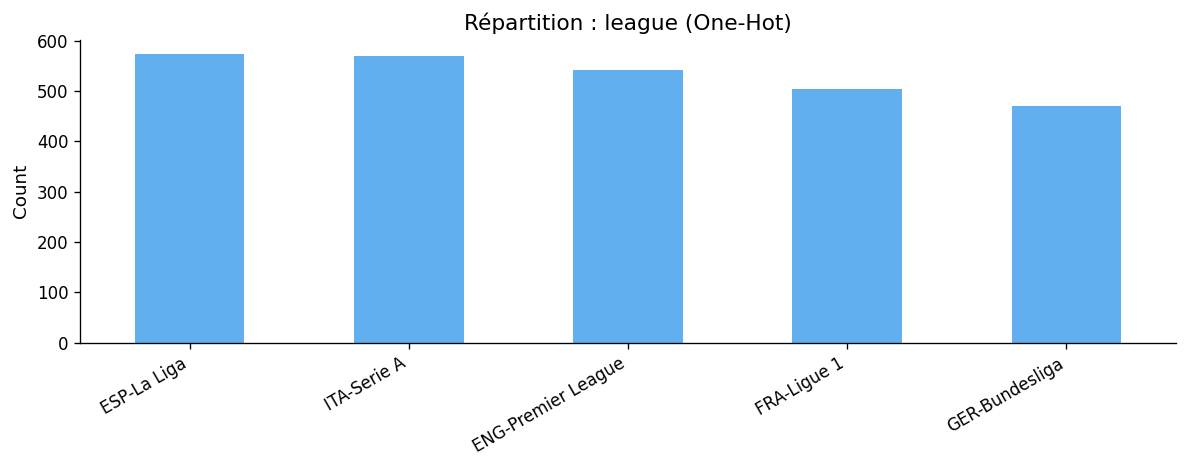

vm_par_league.png sauvegardé


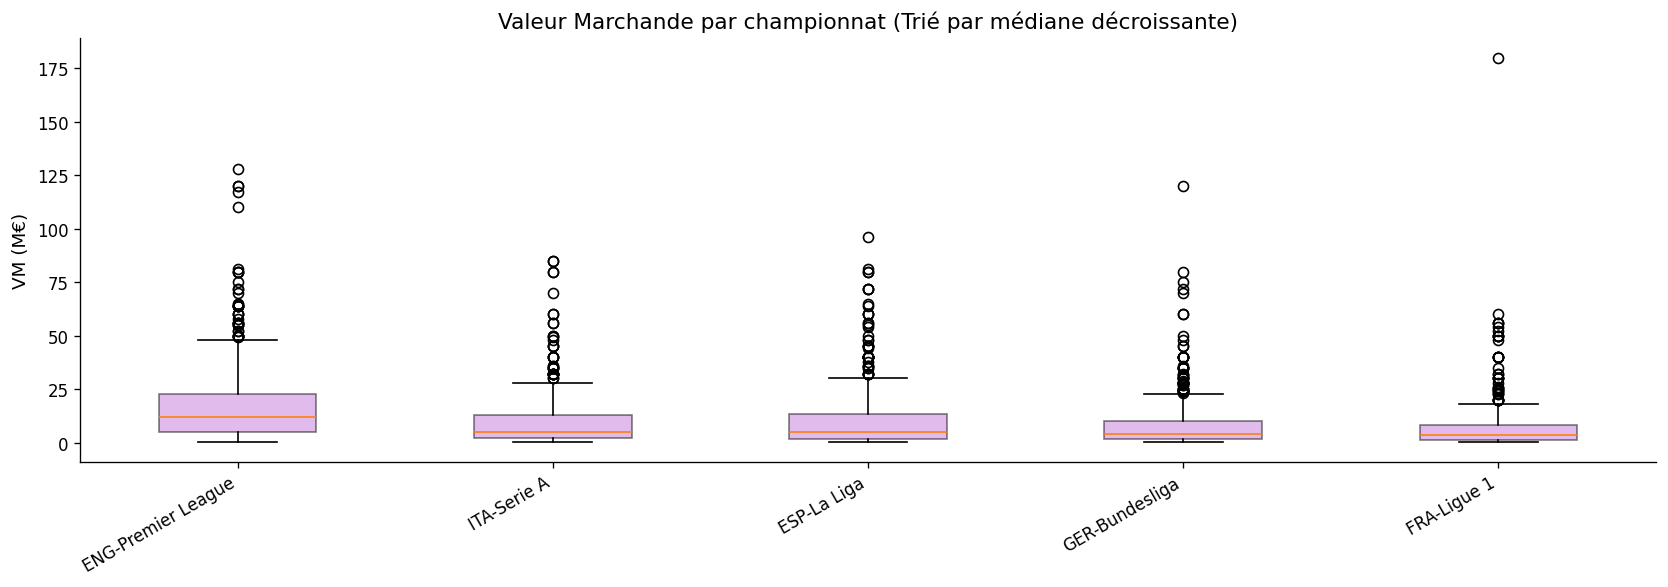

In [8]:
analyser_variables_categorielles(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

In [9]:
analyser_outliers(df_base)

Détection des outliers
         variable  outliers_IQR  pct_IQR  outliers_Zscore  total
              age             4      0.2                4   2661
  Performance_Gls           257      9.7               67   2661
  Performance_Ast           142      5.3               65   2661
               xg           164      9.5               41   1735
               xa           120      6.9               37   1735
injury_days_total           227      8.5               49   2661
  injury_nb_total            39      1.5               39   2661


Analyse des corrélations (cible : market_value_in_eur)

Corrélation linéaire avec la cible (variables clés)
                     market_value_in_eur
market_value_in_eur             1.000000
xg                              0.386645
xa                              0.376579
Performance_Gls                 0.371668
Performance_Ast                 0.324381
injury_nb_total                 0.213221
age                             0.120938
injury_days_total               0.109628

matrice_correlation.png sauvegardé sous : ..\outputs\eda\matrice_correlation.png


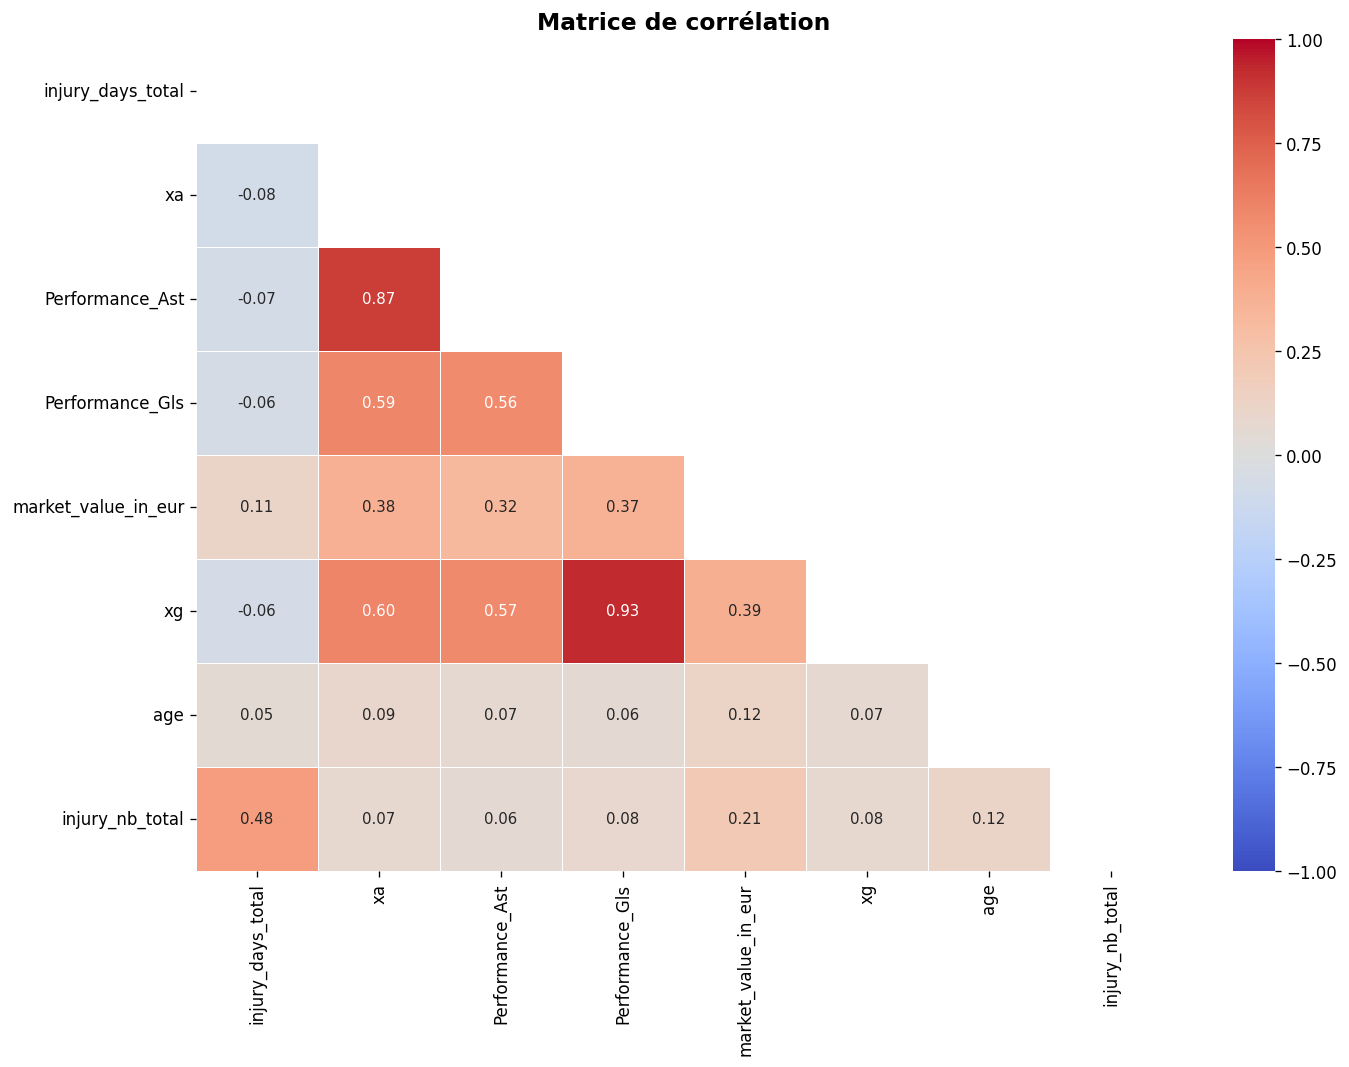


Top 20 des corrélations absolues avec market_value_in_eur (Toutes variables numériques)
market_value_in_eur_nor    1.000000
Team Success_onG           0.414241
xg_buildup_nor             0.398451
xg_buildup                 0.398451
xg                         0.386645
xg_nor                     0.386645
xa_nor                     0.376579
xa                         0.376579
Performance_Gls_nor        0.371668
Performance_Gls            0.371668
Performance_G-PK           0.365669
Standard_SoT_nor           0.365071
Standard_SoT               0.365071
Standard_Sh_nor            0.348479
Standard_Sh                0.348479
Performance_Ast            0.324381
Performance_Ast_nor        0.324381
Team Success_PPM_nor       0.310934
Team Success_PPM           0.310934
Performance_Off            0.239575


In [10]:
analyser_correlations(df_base, TARGET, cols_cles=None, dossier_sauvegarde=dossier_sauvegarde)

## Segmentation par poste

Analyse du profil médian par poste

Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_profil_poste.png


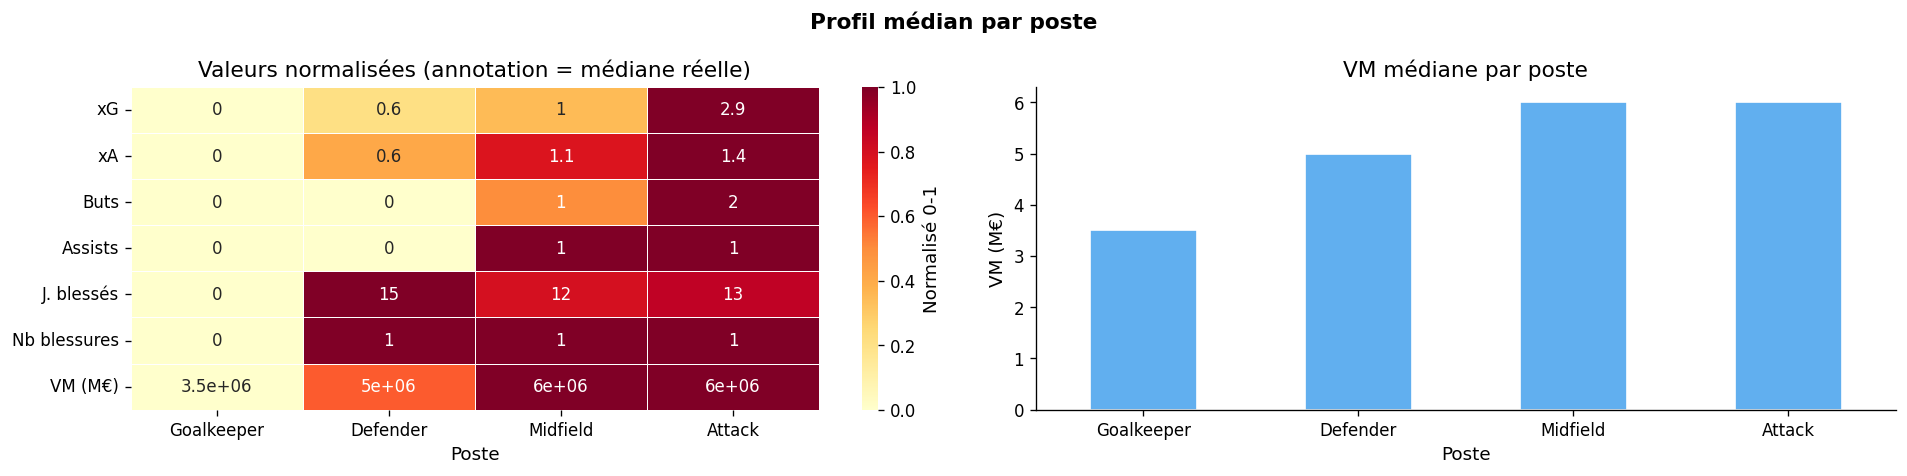

In [11]:
analyser_profil_par_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse de la distribution des âges par poste
Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_age_par_poste.png


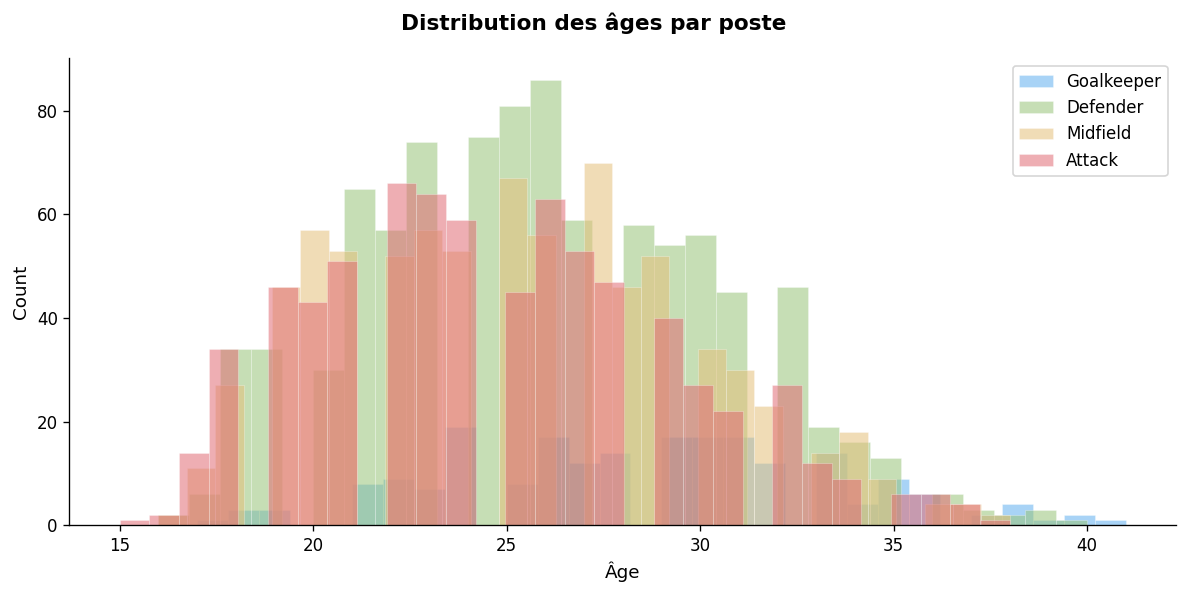


Âge médian par poste
position
Goalkeeper    29.0
Defender      26.0
Midfield      25.0
Attack        24.0


In [12]:
analyser_ages_par_poste(df_base, dossier_sauvegarde=dossier_sauvegarde, liste_couleurs=None)

Analyse croisée : VM médiane par championnat et par poste

Heatmap sauvegardée sous : ..\outputs\eda\feature_engineered_heatmap_league_pos.png


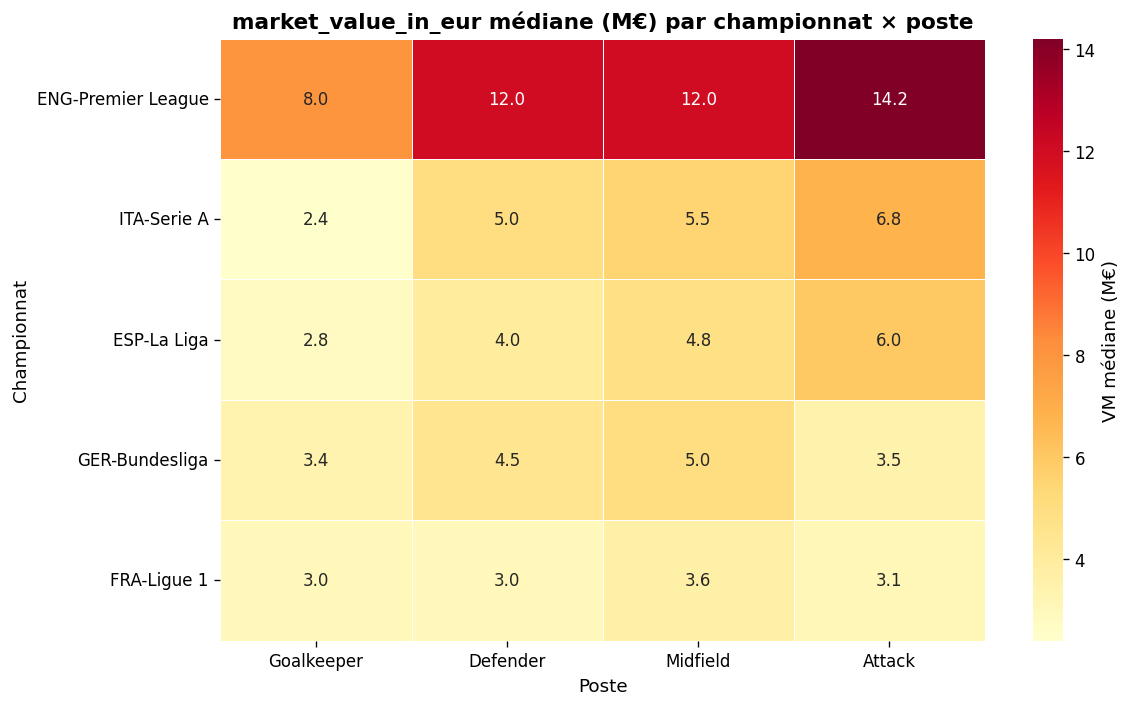

In [13]:
analyser_heatmap_league_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la distribution par championnat

Violin plot sauvegardé sous : ..\outputs\eda\feature_engineered_violin_league.png


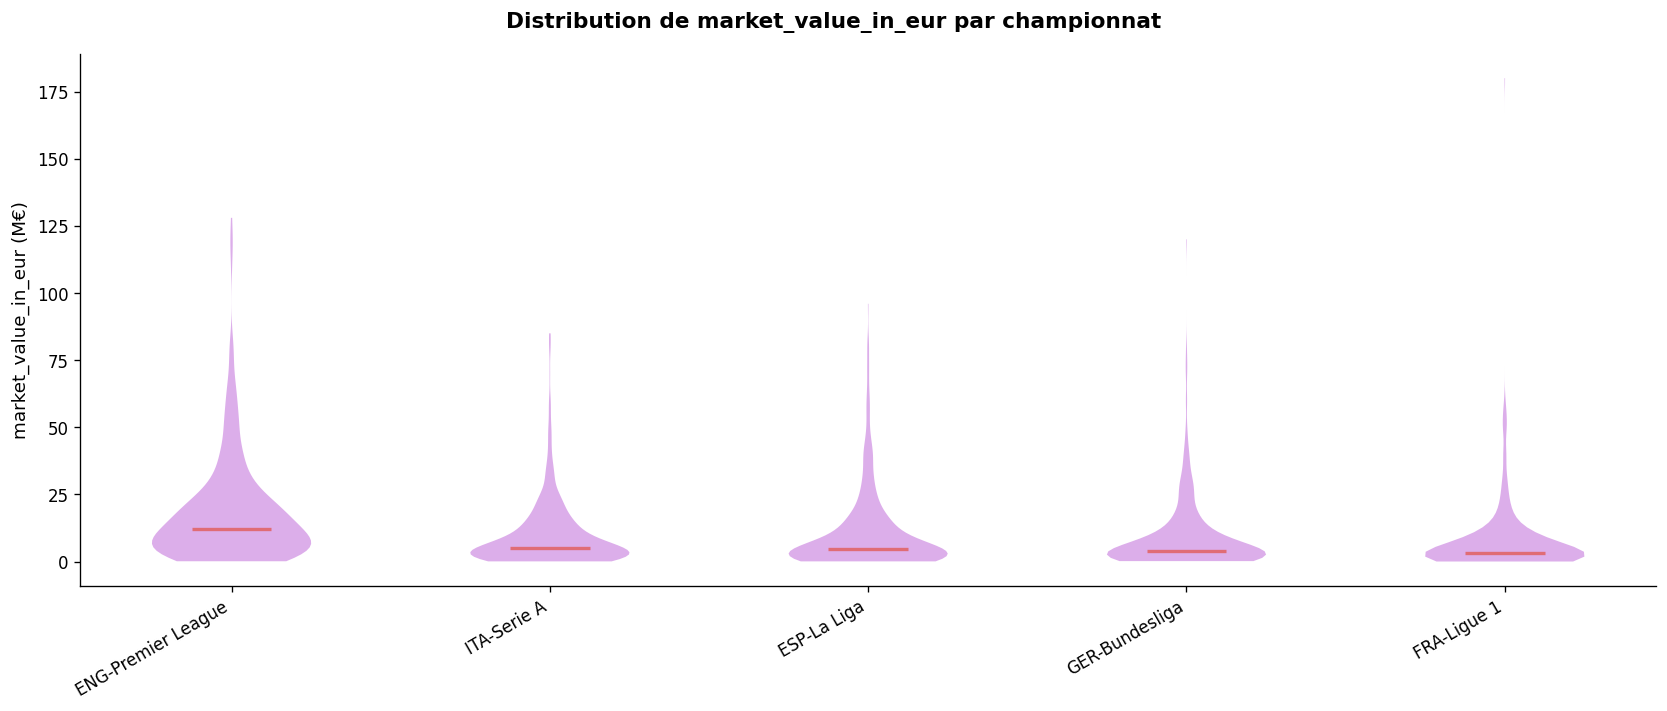

In [14]:
analyser_distribution_violin_league(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des outliers et profils Spécifiques (cible : market_value_in_eur)

Joueurs avec market_value_in_eur ≥ 100M€ : 7 observations

Top 20 des joueurs les plus chers
                player position  age  market_value_in_eur        xg  Performance_Gls  injury_days_total
         Kylian Mbappé   Attack   25                180.0       NaN               27                0.0
       Raheem Sterling   Attack   29                128.0  8.573791                8               17.0
            Harry Kane   Attack   30                120.0 33.116345               36               35.0
         Mohamed Salah   Attack   31                120.0 21.941274               18               41.0
       Kevin De Bruyne Midfield   32                120.0  2.578735                4              151.0
          Jadon Sancho   Attack   23                117.0       NaN                2               16.0
Trent Alexander-Arnold Defender   25                110.0  2.745258                3              103.0


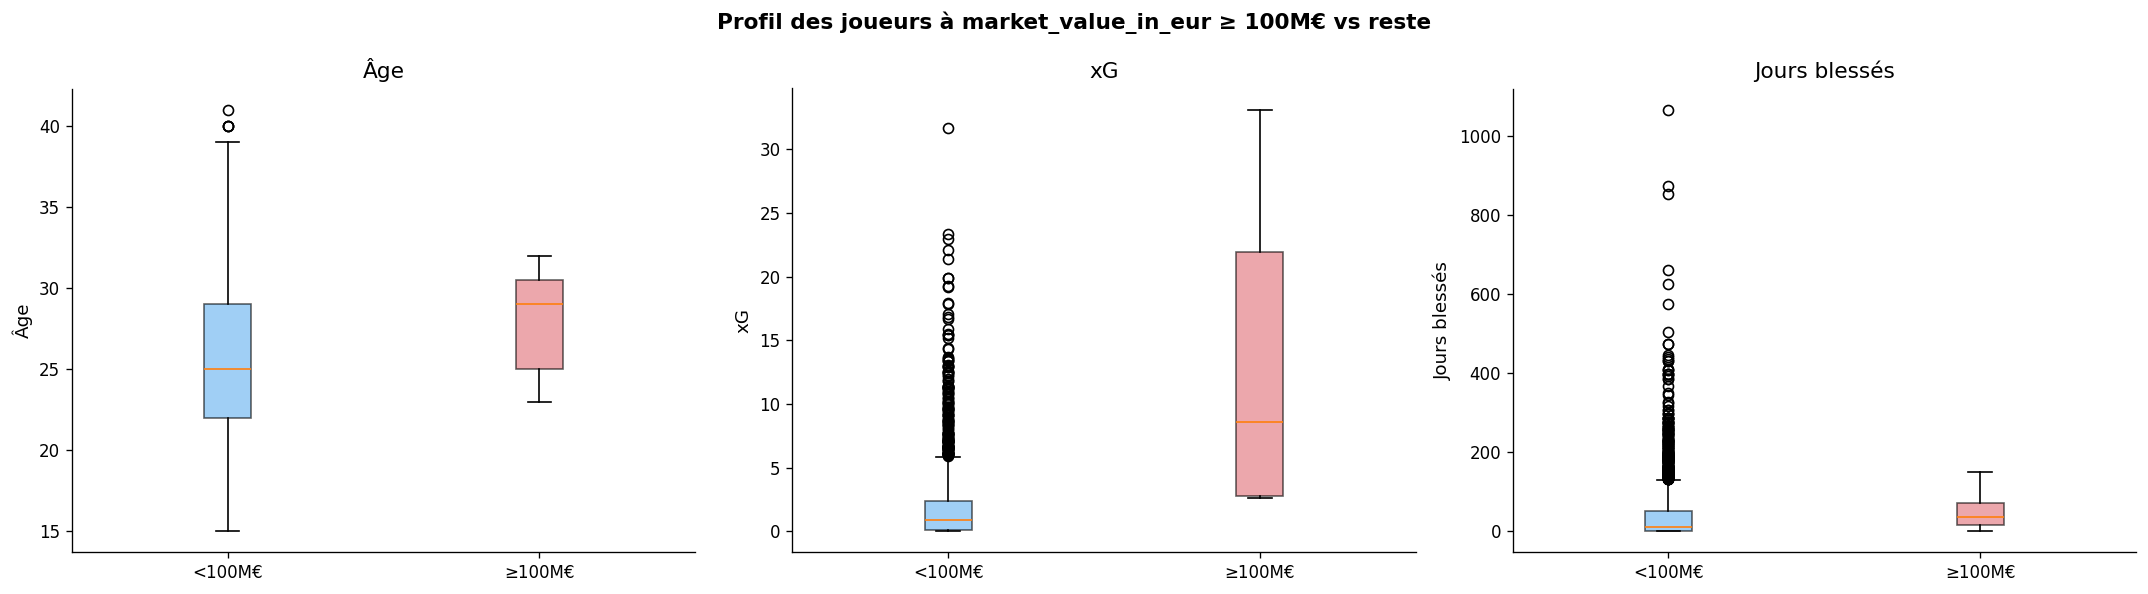

In [15]:
analyser_profil_outliers(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

In [16]:
verifier_coherence_jours_blessures(df_base)

Contrôle de cohérence : jours de blessures

Cohérence injury_days_total vs somme des composantes (2661/2661 lignes analysées) :
  Cohérents (diff = 0)           : 2,544
  Diff ≤ 1 jour                  : 2,544
  Diff > 1 jour (anomalie)       : 117
  Diff max                       : 874 jours

Des incohérences ont été détectées. Cela peut provenir de blessures
 qui se chevauchent dans le temps ou de catégories non répertoriées ici.


Analyse de l'évolution temporelle par Saison (cible : market_value_in_eur)

Évolution VM par saison :
             Médiane (M€)  Moyenne (M€)  Nb joueurs
season_year                                        
2023                  5.4     10.965209        2515

Graphique sauvegardé sous : ..\outputs\eda\evolution_temporelle.png


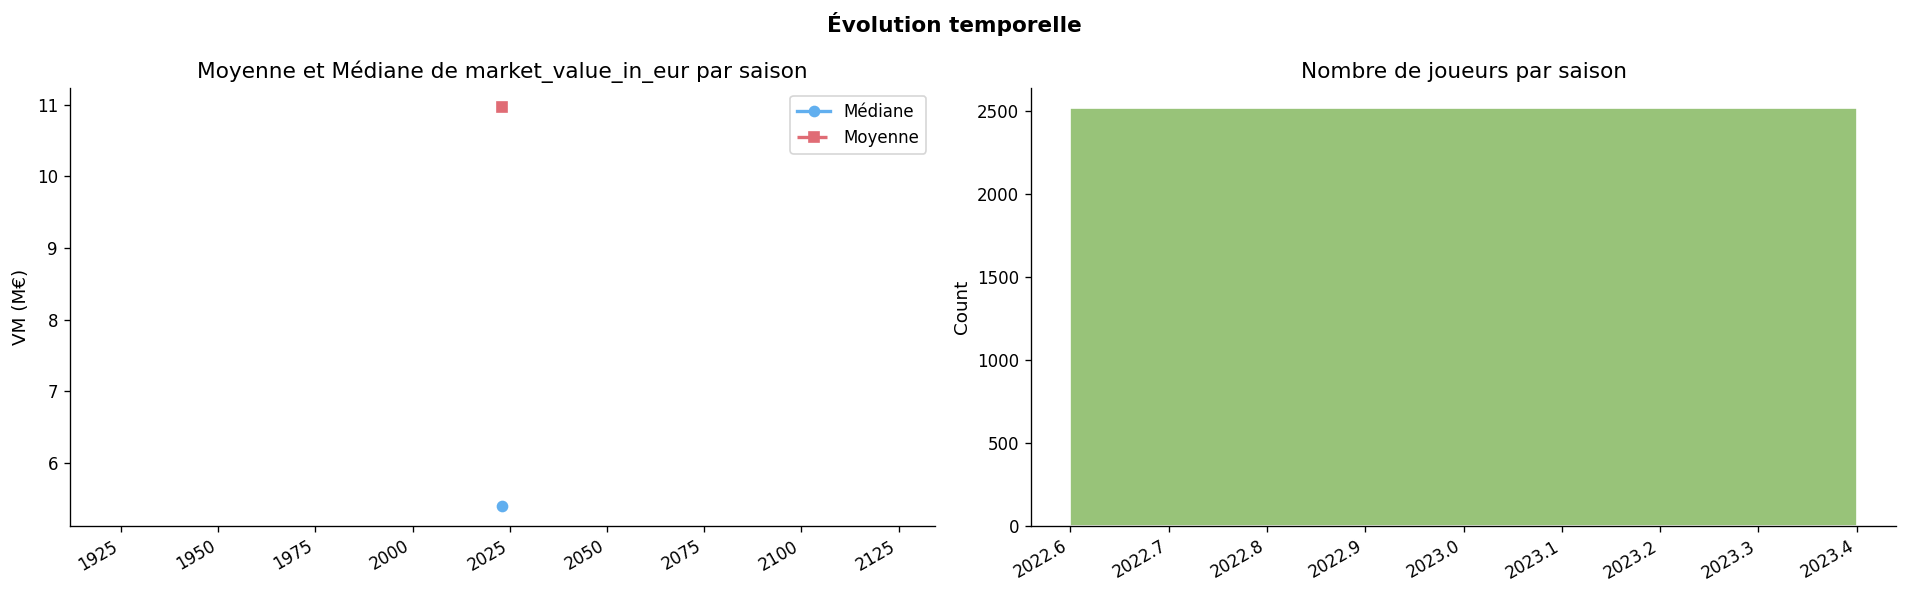

,Médiane (M€),Moyenne (M€),Nb joueurs
season_year,,,
2023,5.4,10.965209,2515


In [17]:
analyser_evolution_temporelle_saison(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Démarrage de l'analyse du cycle de vie financier...
2661 observations valides trouvées pour l'analyse graphique.


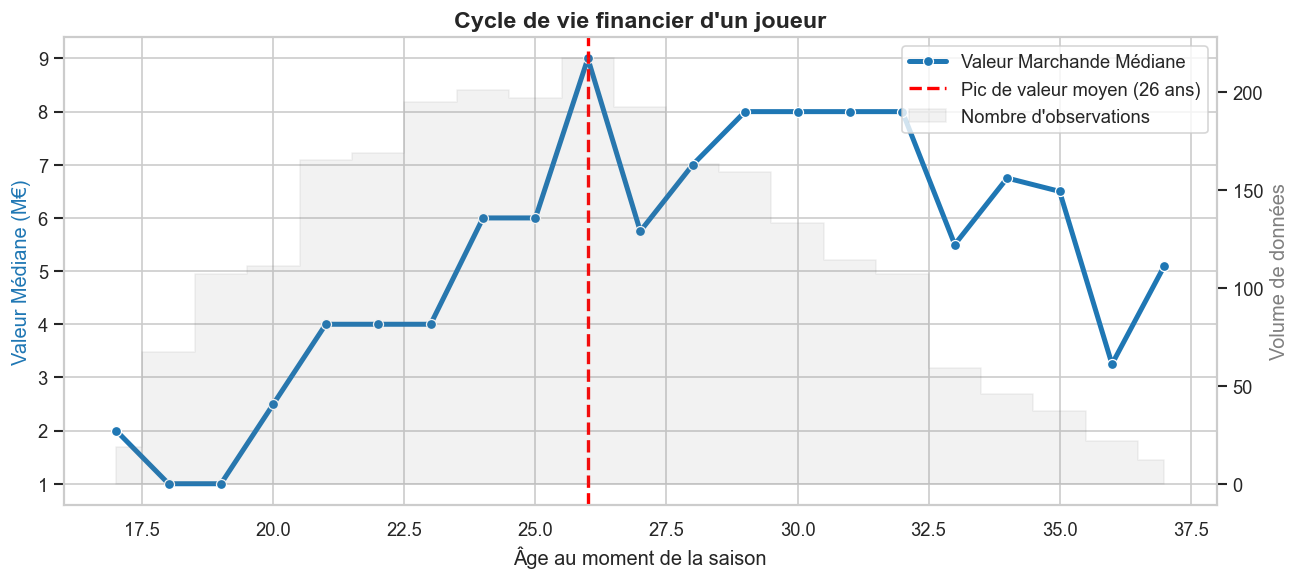


Graphique généré avec succès.


In [18]:
# Application de la fonction
df_base = analyser_cycle_vie_financier(df_base)

Démarrage de l'analyse de distribution des prix...
5 championnats détectés et ordonnés pour l'affichage.


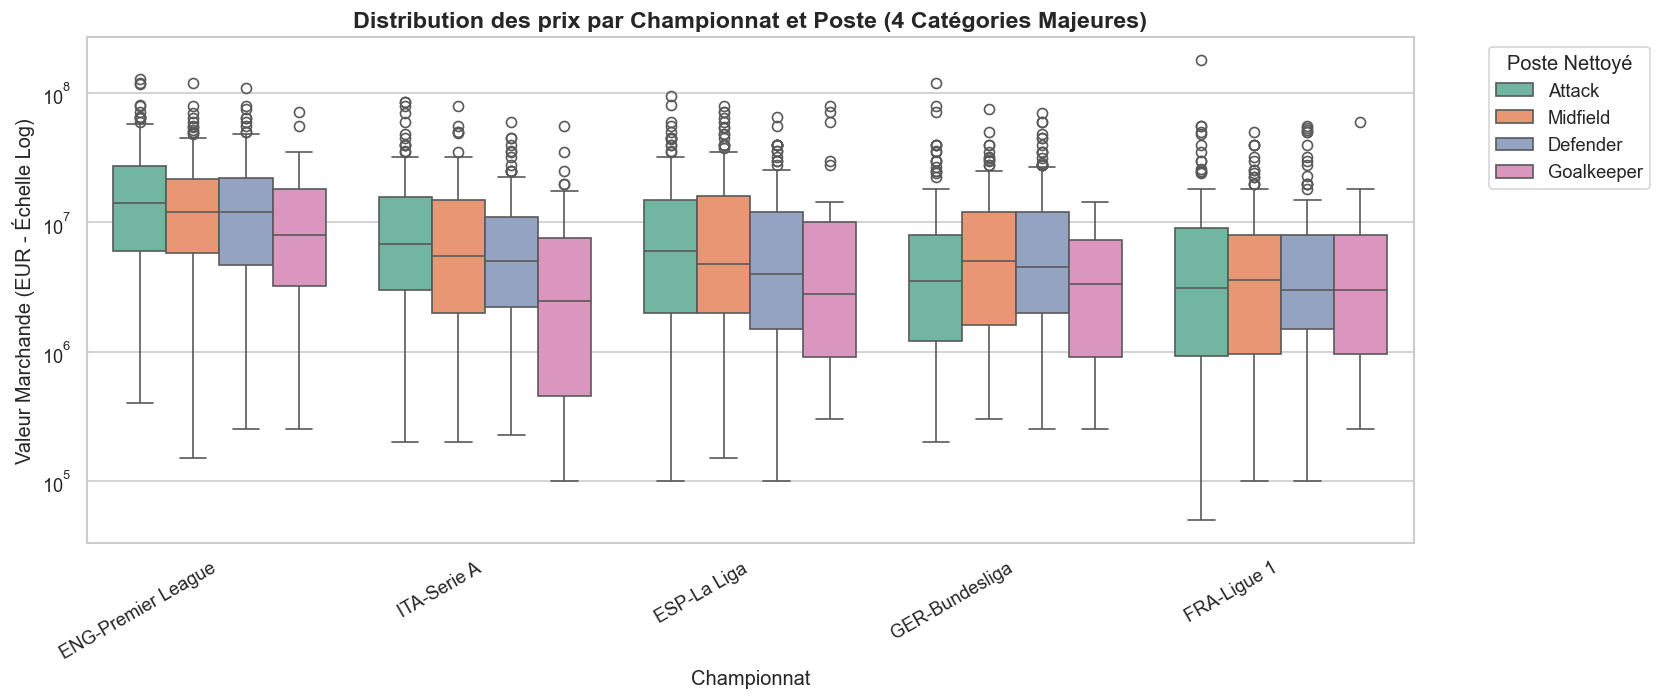


Boxplot généré avec succès.


In [19]:
analyser_distribution_prix_ligue_poste(df_base)

In [20]:
# On détecte les colinéarités
colinearites = detecter_top_colinearites(df_base, top_n=30)

# On affiche le tableau
display(colinearites)

Extraction du Top 30 des colinéarités (hors variables normalisées)...


,Variable_A,Variable_B,Correlation
0,Playing Time_90s,Playing Time_Starts,0.994
1,Performance_G-PK,Performance_Gls,0.979
2,Performance_Saves,Performance_GA,0.976
3,injury_trauma_severe_nb_m,injury_trauma_severe_nb_d,0.968
4,injury_genou_nb_m,injury_genou_nb_d,0.967
5,Performance_PKatt,Performance_PK,0.966
6,pos_GK,Performance_Save%,0.960
7,injury_dos_bassin_nb_m,injury_dos_bassin_nb_d,0.958
8,injury_musculaire_nb_m,injury_musculaire_nb_d,0.957
9,Standard_SoT,Standard_Sh,0.957


In [21]:
df_base

,player,team,nation,age,Playing Time_MP,Playing Time_Starts,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G-PK,...,Performance_CS%_nor,Standard_Sh_nor,Standard_SoT_nor,Standard_SoT%_nor,Standard_G/Sh_nor,Standard_G/SoT_nor,Team Success_PPM_nor,xg_nor,xa_nor,xg_buildup_nor
0,Aaron Cresswell,West Ham United,ENG,34,11,4,4.8,0,0,0,...,0.000,0.000000,0.000000,0.0000,0.00,0.000,0.173913,NaN,NaN,NaN
1,Aaron Hickey,Brentford,SCO,21,9,9,7.9,0,0,0,...,0.000,0.035897,0.010989,0.1429,0.00,0.000,0.193043,0.005906,0.002908,0.040458
2,Aaron Malouda,Lille,FRA,18,1,0,0.0,0,0,0,...,0.000,0.000000,0.000000,0.0000,0.00,0.000,0.521739,0.000000,0.000000,0.000000
3,Aaron Ramsdale,Arsenal,ENG,25,6,6,6.0,0,0,0,...,0.333,0.000000,0.000000,0.0000,0.00,0.000,0.464348,0.000000,0.000000,0.031706
4,Aaron Ramsey,Burnley,ENG,33,14,5,5.9,0,0,0,...,0.000,0.030769,0.021978,0.3333,0.00,0.000,0.062609,0.012271,0.023991,0.021601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2656,Ørjan Nyland,Sevilla,NOR,33,24,24,24.0,0,0,0,...,0.208,0.000000,0.000000,0.0000,0.00,0.000,0.240000,0.000000,0.020583,0.207124
2657,Đorđe Petrović,Chelsea,SRB,24,23,22,22.1,0,0,0,...,0.182,0.000000,0.000000,0.0000,0.00,0.000,0.332174,NaN,NaN,NaN
2658,İlkay Gündoğan,Barcelona,GER,33,36,33,33.3,5,9,4,...,0.000,0.220513,0.186813,0.3953,0.12,0.145,0.380870,NaN,NaN,NaN
2659,Łukasz Fabiański,West Ham United,POL,38,10,7,8.0,0,0,0,...,0.143,0.000000,0.000000,0.0000,0.00,0.000,0.191304,NaN,NaN,NaN


Analyse des variables les plus explicatives pour : market_value_in_eur
Filtrage appliqué : Analyse exclusive des Gardiens de but.


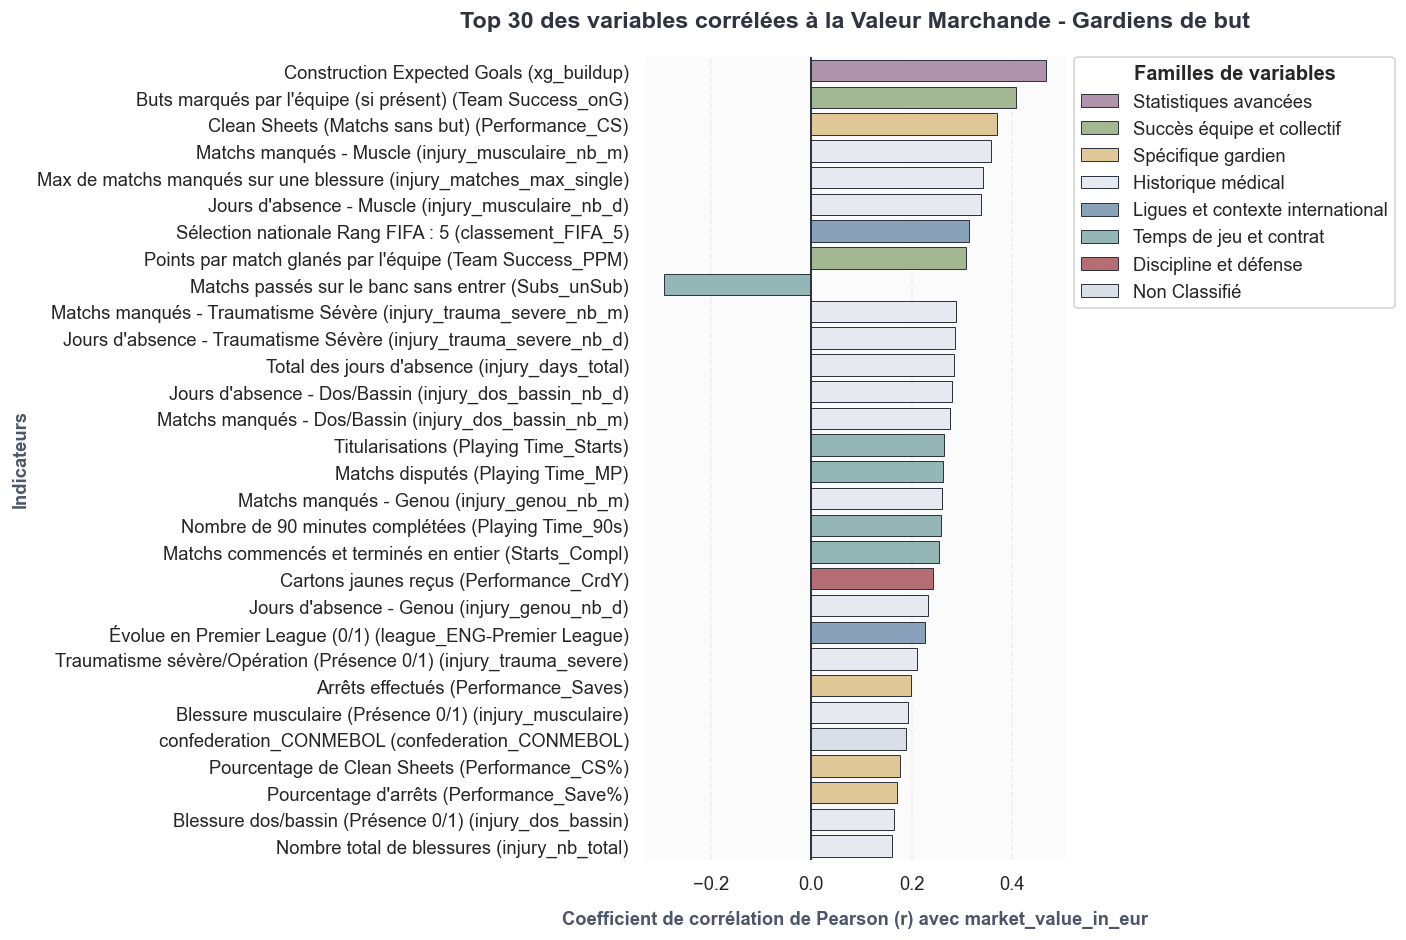

,Variable,Description,Famille,Corr_Cible_Brute
0,xg_buildup,Construction Expected Goals (xg_buildup),Statistiques avancées,0.468
1,Team Success_onG,Buts marqués par l'équipe (si présent) (Team S...,Succès équipe et collectif,0.407
2,Performance_CS,Clean Sheets (Matchs sans but) (Performance_CS),Spécifique gardien,0.369
3,injury_musculaire_nb_m,Matchs manqués - Muscle (injury_musculaire_nb_m),Historique médical,0.357
4,injury_matches_max_single,Max de matchs manqués sur une blessure (injury...,Historique médical,0.342
5,injury_musculaire_nb_d,Jours d'absence - Muscle (injury_musculaire_nb_d),Historique médical,0.337
6,classement_FIFA_5,Sélection nationale Rang FIFA : 5 (classement_...,Ligues et contexte international,0.313
7,Team Success_PPM,Points par match glanés par l'équipe (Team Suc...,Succès équipe et collectif,0.307
8,Subs_unSub,Matchs passés sur le banc sans entrer (Subs_un...,Temps de jeu et contrat,-0.294
9,injury_trauma_severe_nb_m,Matchs manqués - Traumatisme Sévère (injury_tr...,Historique médical,0.288


In [22]:
# On applique la fonction
tableau_importance = analyser_variables_les_plus_explicatives(df_base,
                                                              target_col=TARGET,
                                                              top_n=30,
                                                              afficher_nom_technique=True,
                                                              uniquement_gardiens=True)

# On affiche le tableau propre sous le graphique
display(tableau_importance)

In [24]:
# Filtrez sur les gardiens uniquement avant de calculer la corrélation
df_gardiens = df_base[df_base["pos_GK"] == 1]

# Calculez la corrélation pearson
print(df_gardiens[["Performance_GA", "market_value_in_eur"]].corr())

                     Performance_GA  market_value_in_eur
Performance_GA             1.000000             0.111104
market_value_in_eur        0.111104             1.000000


In [25]:
# Corrélation brute
print(df_gardiens[["Performance_GA", "market_value_in_eur"]].corr())

# Corrélation entre les buts encaissés et la VM, mais à temps de jeu strictement égal
p_corr = pg.partial_corr(
    data=df_gardiens,
    x="Performance_GA",
    y="market_value_in_eur",
    covar="Playing Time_90s",
)

print(p_corr)

                     Performance_GA  market_value_in_eur
Performance_GA             1.000000             0.111104
market_value_in_eur        0.111104             1.000000
           n         r            CI95     p_val
pearson  191 -0.285766  [-0.41, -0.15]  0.000064


La corrélation à temps de jeu égal est bien négative : $-0.479881$, une valeur plus élevée que la corrélation de la colonne Performance_GA90 ($-0,20$). 

C'est parce que la variable Performance_GA90 (buts/90min) souffre d'un autre biais : le biais des petits échantillons.
Exemple : Un gardien remplaçant très faible entre en jeu, joue 10 minutes et prend 2 buts. Son ratio par 90 minutes explose (il monte à $18,0$ buts par match !). 

Ce genre de valeur extrême (outlier) vient "bruiter" et affaiblir votre corrélation Pearson classique sur la colonne des ratios.
La corrélation partielle, elle, étudie les volumes bruts sous contrôle mathématique. Elle contourne ce bruit des ratios extrêmes sur des petits temps de jeu, ce qui donne la vraie mesure de l'impact négatif des buts encaissés sur la valeur marchande d'un gardien.